<div style='padding:20px; background:lightblue;color:black;border-radius:10px'>
  <h1>Giới thiệu tập dữ liệu:</h1>
    <hr />
    <b>Bối cảnh:</b><br />
   Một trong những chuỗi bán lẻ hàng đầu tại Mỹ, Walmart, muốn dự đoán chính xác doanh số bán hàng và nhu cầu. Có một số sự kiện và ngày lễ ảnh hưởng đến doanh số bán hàng mỗi ngày. Dữ liệu doanh số bán hàng của 45 cửa hàng Walmart có sẵn. Doanh nghiệp đang gặp khó khăn do nhu cầu bất ngờ, dẫn đến tình trạng hết hàng trong một số trường hợp, nguyên nhân là do thuật toán học máy không phù hợp. Một thuật toán học máy lý tưởng sẽ dự đoán chính xác nhu cầu và tính đến các yếu tố như điều kiện kinh tế, bao gồm CPI, Chỉ số Thất nghiệp, v.v.

Walmart thực hiện nhiều chương trình giảm giá khuyến mãi trong năm. Những chương trình giảm giá này diễn ra trước các ngày lễ lớn, gồm 4 ngày lễ quan trọng nhất: Super Bowl, Ngày Lao động, Lễ Tạ ơn và Giáng sinh. Các tuần bao gồm các ngày lễ này được đánh giá cao gấp 5 lần so với các tuần không có ngày lễ trong việc đánh giá. Một phần thách thức trong bài toán này là mô hình hóa tác động của các chương trình giảm giá trong các tuần lễ ngày lễ khi thiếu dữ liệu lịch sử đầy đủ hoặc lý tưởng. Dữ liệu doanh số lịch sử của 45 cửa hàng Walmart tại các khu vực khác nhau đã có sẵn.
    
</div>

Đây là dữ liệu lịch sử bao gồm doanh số bán hàng từ ngày 05-02-2010 đến ngày 01-11-2012, được lưu trong tệp Walmart_Store_Sales.

| Variable      | Description                                                                                                 |
| ------------- | ----------------------------------------------------------------------------------------------------------- |
| Store            |ID cửa hàng                                                        |
| Date        |Tuần bán hàng                                                                                         |
| Weekly_Sales         |Doanh số bán hàng theo tuần cho cửa hàng                                                              |
| Holiday_Flag      | Tuần lễ đặc biệt (1 – Tuần lễ ngày lễ, 0 – Tuần thường)                                                                      |
| Temperature     |  Nhiệt độ trong ngày bán hàng                                                                        |
| Fule_Price   | Giá nhiên liệu tại khu vực                                                         |
| CPI      | Chỉ số giá tiêu dùng hiện tại                                                               |
| Unemployment        | Chỉ số giá tiêu dùng hiện tại                                                    |
| Holiday Events    | Super Bowl: 12-Feb-10, 11-Feb-11, 10-Feb-12, 8-Feb-13 Ngày Lao động: 10-Sep-10, 9-Sep-11, 7-Sep-12, 6-Sep-13Lễ Tạ ơn: 26-Nov-10, 25-Nov-11, 23-Nov-12, 29-Nov-13 Giáng sinh: 31-Dec-10, 30-Dec-11, 28-Dec-12, 27-Dec-13                         

In [ ]:
!pip install scikit-learn==1.2.2 --upgrade

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,learning_curve
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb

In [ ]:
path="Walmart.csv"

In [ ]:
# import the dataset
df = pd.read_csv(path)

In [ ]:
walmart_df = df.copy()


  #  1- Đọc dữ liệu


<div style='padding:10px; background:lightgreen;border-radius:5px'>
    Dữ liệu có cấu trúc được lưu trữ thế nào?
    </div>

In [ ]:
#xem 5 dòng dầu tiên
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,"1,643,690.90",0,42.31,2.57,211.10,8.11
1,1,12-02-2010,"1,641,957.44",1,38.51,2.55,211.24,8.11
2,1,19-02-2010,"1,611,968.17",0,39.93,2.51,211.29,8.11
3,1,26-02-2010,"1,409,727.59",0,46.63,2.56,211.32,8.11
4,1,05-03-2010,"1,554,806.68",0,46.50,2.62,211.35,8.11


In [ ]:
print("Số lượng dòng:", df.shape[0])
print("So lượng cột:", df.shape[1])

Số lượng dòng: 6435
So lượng cột: 8


# 2- Kiểm tra và xử lý dữ liệu

## Kiểm tra


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


Dữ liệu về ngày chưa được xác định


In [ ]:
df.Date = pd.to_datetime(df.Date, format='%d-%m-%Y')
# Hiển thị số liệu đầy đủ thay vì dạng khoa học
pd.set_option('display.float_format', '{:,.2f}'.format)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


Kiểu dữ liệu hiện tại phù hợp để phân tích và dự đoán.

In [ ]:
# Kiểm tra số lượng giá trị bị thiếu trong từng cột
missing_values = df.isna().sum()
print("Số lượng giá trị bị thiếu trong mỗi cột:")
print(missing_values)

Số lượng giá trị bị thiếu trong mỗi cột:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


In [ ]:
# Kiểm tra giá trị trùng lắp
print("Số lượng giá trị trùng lặp:",df.duplicated().sum())

Số lượng giá trị trùng lặp: 0


In [ ]:
df.loc[df['Weekly_Sales']<=0]

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment


Bộ dữ liệu không bị thiếu hay có sự trùng lắp về dữ liệu. Không có doanh thu nhỏ hoặc bằng không dữ liệu khá tốt.

## Thống kê cơ bản

In [ ]:
cate_features = ['Store','Date','Holiday_Flag']
numeric_features = list(set(df.columns)  - set(cate_features))

print ('Categorical features:', cate_features)
print ('Numerical features: ', numeric_features)

Categorical features: ['Store', 'Date', 'Holiday_Flag']
Numerical features:  ['Fuel_Price', 'Temperature', 'Unemployment', 'Weekly_Sales', 'CPI']


### Thống kê Categorical Features

In [ ]:
print("Số lượng store:", df['Store'].nunique())
store_sales_sum = df.groupby('Store')['Weekly_Sales'].sum()

# Sắp xếp giảm dần theo tổng doanh thu
top_5_stores = store_sales_sum.sort_values(ascending=False).head(5)
top_5_stores


Số lượng store: 45


,Weekly_Sales
Store,
20,"301,397,792.46"
4,"299,543,953.38"
14,"288,999,911.34"
13,"286,517,703.80"
2,"275,382,440.98"


In [ ]:
# Tần suất và phần trăm của từng biến
holiday_freq = df['Holiday_Flag'].value_counts()
holiday_percent = df['Holiday_Flag'].value_counts(normalize=True) * 100
holiday_table = pd.DataFrame({
    'Frequency': holiday_freq,
    'Percentage': holiday_percent
})
holiday_table

,Frequency,Percentage
Holiday_Flag,,
0,5985,93.01
1,450,6.99



* Ngày thường chiếm ưu thế: Hơn 93% số ngày trong tập dữ liệu là những ngày thường (5985 ngày).
* Ngày lễ chiếm tỷ lệ nhỏ: Chỉ có khoảng 6.99% số ngày là ngày lễ (450 ngày).

### Thống kê cho Numerical Features

In [ ]:
df.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,"6,435.00",6435,"6,435.00","6,435.00","6,435.00","6,435.00","6,435.00","6,435.00"
mean,23.00,2011-06-17 00:00:00,"1,046,964.88",0.07,60.66,3.36,171.58,8.00
min,1.00,2010-02-05 00:00:00,"209,986.25",0.00,-2.06,2.47,126.06,3.88
25%,12.00,2010-10-08 00:00:00,"553,350.10",0.00,47.46,2.93,131.74,6.89
50%,23.00,2011-06-17 00:00:00,"960,746.04",0.00,62.67,3.44,182.62,7.87
75%,34.00,2012-02-24 00:00:00,"1,420,158.66",0.00,74.94,3.73,212.74,8.62
max,45.00,2012-10-26 00:00:00,"3,818,686.45",1.00,100.14,4.47,227.23,14.31
std,12.99,NaN,"564,366.62",0.26,18.44,0.46,39.36,1.88


1. Weekly_Sales :
  * Doanh thu giữa các cửa hàng có sự chênh lệch lớn.
  * Một số cửa hàng có doanh thu cao vượt trội, gây ra giá trị max rất lớn..
2. Temperature: Nhiệt độ thay đổi đáng kể giữa các tuần.
3. Fuel_Price: Giá nhiên liệu ổn định với biên độ dao động nhỏ.
4. CPI: CPI dao động khá lớn trong khoảng thời gian dữ liệu.
5. Unemployment: dao động từ 3.88% đến 14.31%, gợi ý sự khác biệt về tình hình kinh tế giữa các khu vực hoặc thời kỳ.
--> Cần xem xét thêm vì các features có phân phối chưa được đều


### Kiểm tra Outliers

In [ ]:
numeric_features

['Fuel_Price', 'Temperature', 'Unemployment', 'Weekly_Sales', 'CPI']

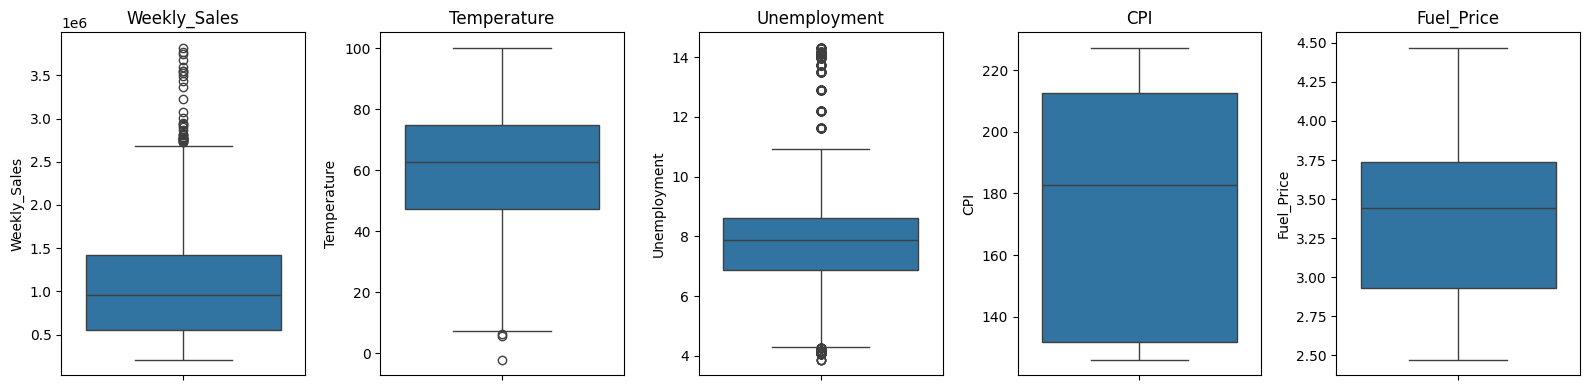

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4))

sns.boxplot(data=df, y='Weekly_Sales', ax=axes[0], orient='v')
axes[0].set_title('Weekly_Sales')

sns.boxplot(data=df, y='Temperature', ax=axes[1], orient='v')
axes[1].set_title('Temperature')

sns.boxplot(data=df, y='Unemployment', ax=axes[2], orient='v')
axes[2].set_title('Unemployment')

sns.boxplot(data=df, y='CPI', ax=axes[3], orient='v')
axes[3].set_title('CPI')

sns.boxplot(data=df, y='Fuel_Price', ax=axes[4], orient='v')
axes[4].set_title('Fuel_Price')

# Tự động sắp xếp các subplot
plt.tight_layout()
plt.show()


In [ ]:
def count_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers)

def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] > lower_bound) & (df[column] < upper_bound)]

In [ ]:
def replace_outliers_with_mean(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mean_value = df[column].mean()
    df[column] = np.where((df[column] < lower_bound) | (df[column] > upper_bound), mean_value, df[column])
    return df



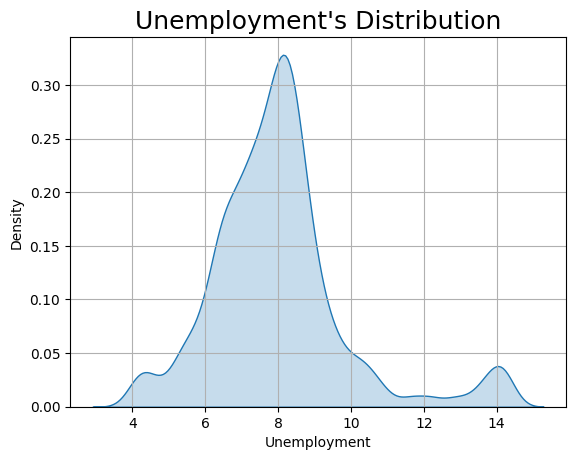

In [ ]:
ax = sns.kdeplot(df["Unemployment"], fill=True)
plt.grid(True)
ax.set_title(f'{"Unemployment"}\'s Distribution', fontdict={'fontsize': 18})
plt.show()

In [ ]:
for col in numeric_features:
    num_outliers = count_outliers(df, col)
    print(f"Number of outliers in {col}: {num_outliers}")

Number of outliers in Fuel_Price: 0
Number of outliers in Temperature: 3
Number of outliers in Unemployment: 481
Number of outliers in Weekly_Sales: 34
Number of outliers in CPI: 0


Vì đã kiểm tra EDA ở dưới nhóm thấy features Unemployment có bị lệch phải nên tiến hành KNN để giảm thiểu ảnh hưởng
Sau khi kiểm tra có thể thấy xuất hiện một số outliers chiếm tỷ lệ nên nhóm em xin thực hiện xóa bởi vì cũng không có ảnh hưởng nhiều

Dữ liệu trước khi xóa outlier: 6435
Dữ liệu sau khi xóa outlier: 6398


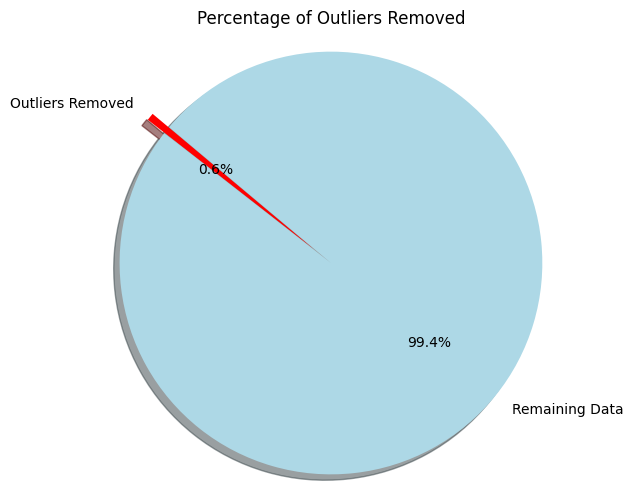

In [ ]:
total_rows_before = df.shape[0]  # Get the initial number of rows in the DataFrame
print("Dữ liệu trước khi xóa outlier:", total_rows_before)
remove_outliers_features=["Weekly_Sales","Temperature"]
for col in remove_outliers_features:
    df = remove_outliers(df, col)
df_replaced = replace_outliers_with_mean(df, 'Unemployment')
total_rows_after = df.shape[0]  # Get the number of rows after removing outliers
print("Dữ liệu sau khi xóa outlier:", total_rows_after)

outliers_removed = total_rows_before - total_rows_after  # Calculate the number of outliers removed
percentage_removed = (outliers_removed / total_rows_before) * 100  # Calculate the percentage of outliers removed

labels = ['Outliers Removed', 'Remaining Data']
sizes = [percentage_removed, 100 - percentage_removed]  # Define the sizes for the pie chart
colors = ['red', 'lightblue']
explode = (0.1, 0)

plt.figure(figsize=(6, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)  # Create the pie chart
plt.title('Percentage of Outliers Removed')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.show()

# 3-EDA Khám phá dữ liệu

## Phân phối của Weekly_Sales

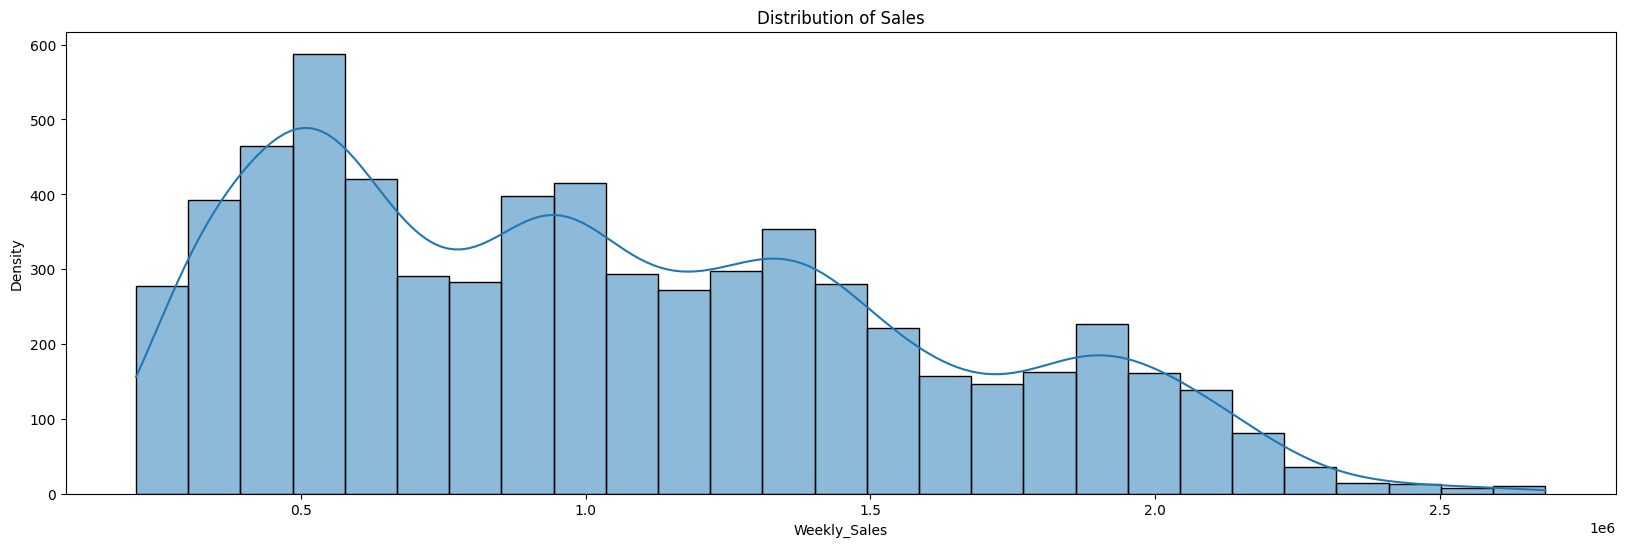

In [ ]:
plt.figure(figsize=(20, 6))
sns.histplot(df['Weekly_Sales'], kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Weekly_Sales')
plt.ylabel('Density')
plt.show()

Phân phối lệch phải, có nghĩa là có một số tuần có doanh số rất cao so với mức trung bình. Điều này cho thấy có sự biến động lớn trong doanh số hàng tuần.

## Categorical Features

In [ ]:
df_holiday = df.loc[df['Holiday_Flag']==1]
df_holiday['Date'].unique()

<DatetimeArray>
['2010-02-12 00:00:00', '2010-09-10 00:00:00', '2010-11-26 00:00:00',
 '2010-12-31 00:00:00', '2011-02-11 00:00:00', '2011-09-09 00:00:00',
 '2011-11-25 00:00:00', '2011-12-30 00:00:00', '2012-02-10 00:00:00',
 '2012-09-07 00:00:00']
Length: 10, dtype: datetime64[ns]

In [ ]:
# Super Bowl dates in train set
df.loc[(df['Date'] == '2010-02-12') | (df['Date'] == '2011-02-11') | (df['Date'] == '2012-02-10'), 'Super_Bowl'] = True
df.loc[(df['Date'] != '2010-02-12') & (df['Date'] != '2011-02-11') & (df['Date'] != '2012-02-10'), 'Super_Bowl'] = False

# Labor Day dates in train set
df.loc[(df['Date'] == '2010-09-10') | (df['Date'] == '2011-09-09') | (df['Date'] == '2012-09-07'), 'Labor_Day'] = True
df.loc[(df['Date'] != '2010-09-10') & (df['Date'] != '2011-09-09') & (df['Date'] != '2012-09-07'), 'Labor_Day'] = False

# Thanksgiving dates in train set
df.loc[(df['Date'] == '2010-11-26') | (df['Date'] == '2011-11-25'), 'Thanksgiving'] = True
df.loc[(df['Date'] != '2010-11-26') & (df['Date'] != '2011-11-25'), 'Thanksgiving'] = False

# Christmas dates in train set
df.loc[(df['Date'] == '2010-12-31') | (df['Date'] == '2011-12-30'), 'Christmas'] = True
df.loc[(df['Date'] != '2010-12-31') & (df['Date'] != '2011-12-30'), 'Christmas'] = False


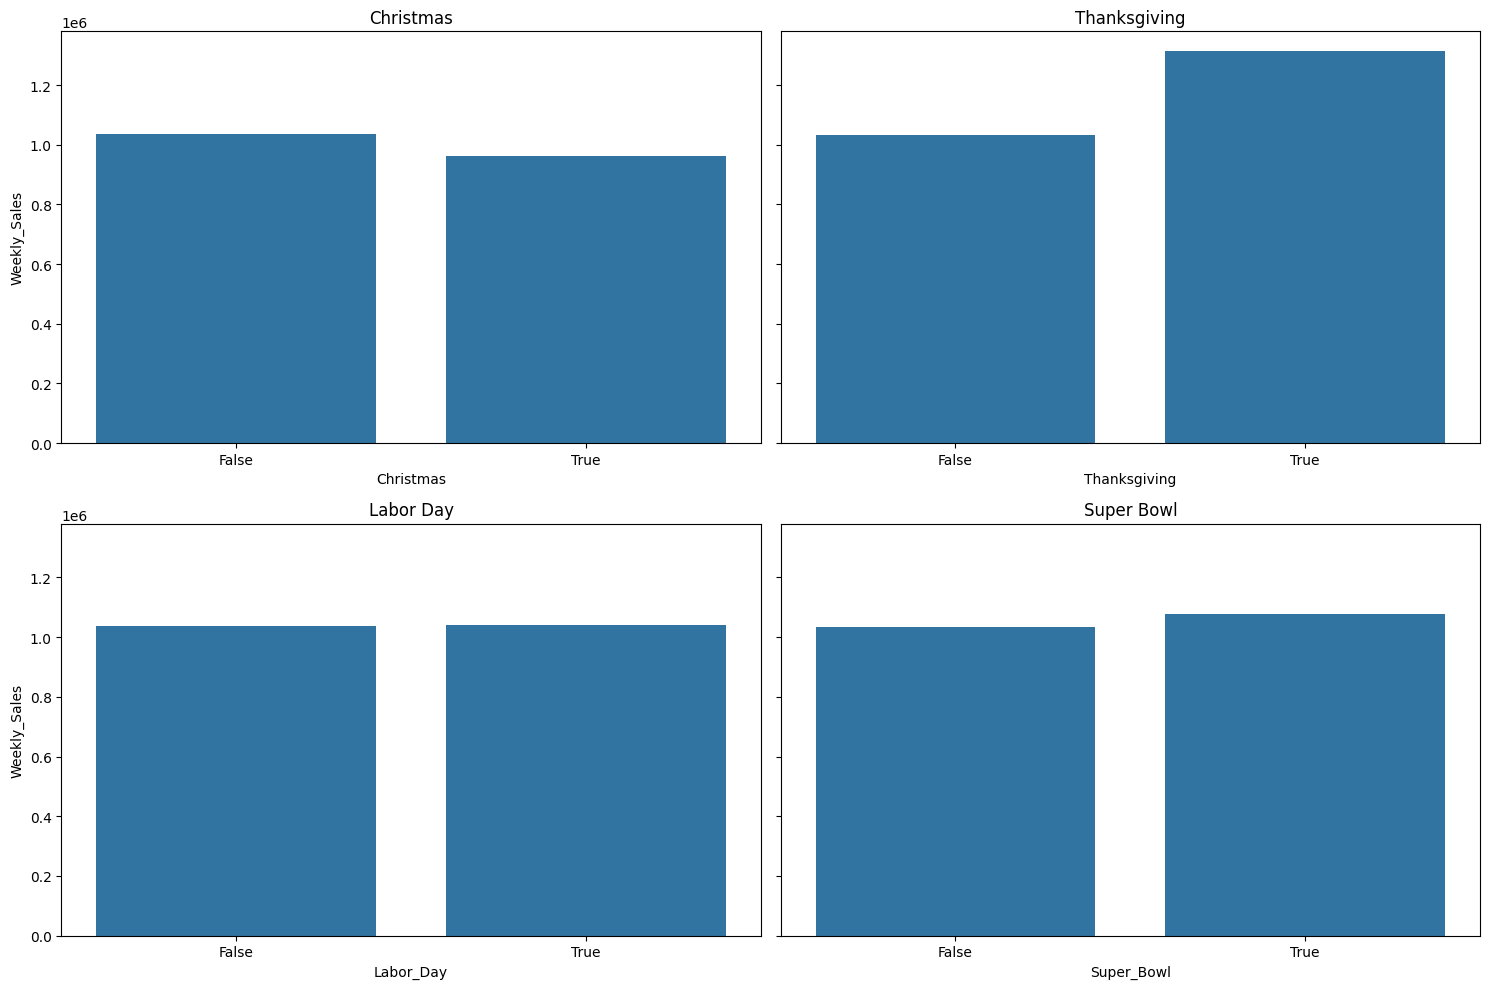

In [ ]:
# Tạo figure và các subplot
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True)

# Barplot cho Christmas
sns.barplot(ax=axes[0, 0], x='Christmas', y='Weekly_Sales', data=df, errorbar=None)
axes[0, 0].set_title('Christmas')

# Barplot cho Thanksgiving
sns.barplot(ax=axes[0, 1], x='Thanksgiving', y='Weekly_Sales', data=df, errorbar=None)
axes[0, 1].set_title('Thanksgiving')

# Barplot cho Labor Day
sns.barplot(ax=axes[1, 0], x='Labor_Day', y='Weekly_Sales', data=df, errorbar=None)
axes[1, 0].set_title('Labor Day')

# Barplot cho Super Bowl
sns.barplot(ax=axes[1, 1], x='Super_Bowl', y='Weekly_Sales', data=df, errorbar=None)
axes[1, 1].set_title('Super Bowl')

# Điều chỉnh khoảng cách giữa các biểu đồ
plt.tight_layout()
plt.show()

Các biểu đồ cho thấy rằng Labor Day và Christmas không làm tăng doanh số trung bình hàng tuần. Có tác động tích cực đến doanh số trong tuần Super Bowl, nhưng sự khác biệt lớn nhất là vào tuần Thanksgiving. Tôi nghĩ rằng mọi người thường thích mua quà Christmas trước 1-2 tuần, vì vậy doanh số không thay đổi nhiều trong tuần Christmas. Và, có các chương trình giảm giá Black Friday trong tuần Thanksgiving.

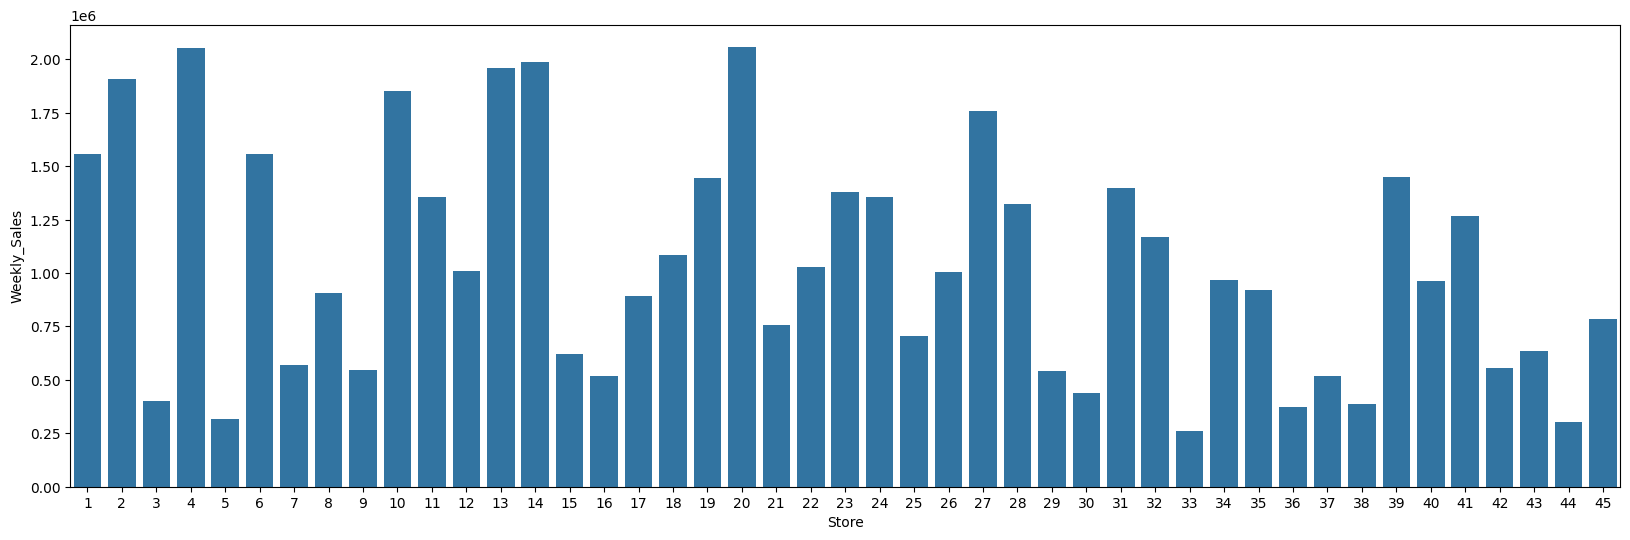

In [ ]:
plt.figure(figsize=(20,6))
fig = sns.barplot(x='Store', y='Weekly_Sales', data=df, errorbar=None)

In [ ]:
df['week'] =df['Date'].dt.isocalendar().week
df['month'] =df['Date'].dt.month
df['year'] =df['Date'].dt.year
df.groupby('year')['Weekly_Sales'].mean()

,Weekly_Sales
year,
2010,"1,040,918.86"
2011,"1,034,056.21"
2012,"1,033,660.39"


<Axes: xlabel='month'>

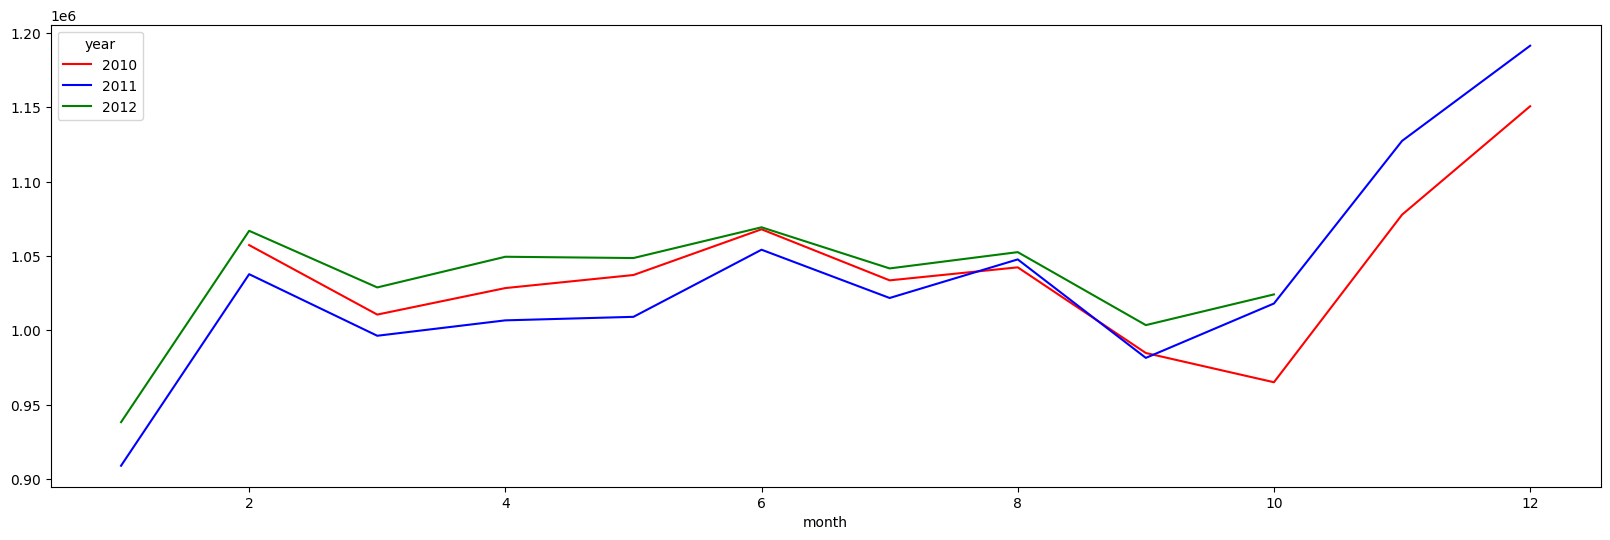

In [ ]:
monthly_sales = pd.pivot_table(df, values = "Weekly_Sales", columns = "year", index = "month")
monthly_sales.plot(figsize=(20,6), color=['red', 'blue', 'green'])

Từ biểu đồ, có thể thấy rằng doanh số năm 2011 thấp hơn so với năm 2010. Khi xem xét doanh số trung bình, có thể thấy rằng năm 2010 có giá trị cao hơn, nhưng năm 2012 không có thông tin về tháng 11 và tháng 12, những tháng có doanh số cao hơn. Mặc dù năm 2012 không có doanh số của hai tháng cuối năm, nhưng trung bình của nó gần bằng năm 2010. Rất có thể, nó sẽ đứng đầu nếu chúng ta có kết quả của năm 2012 và thêm vào.

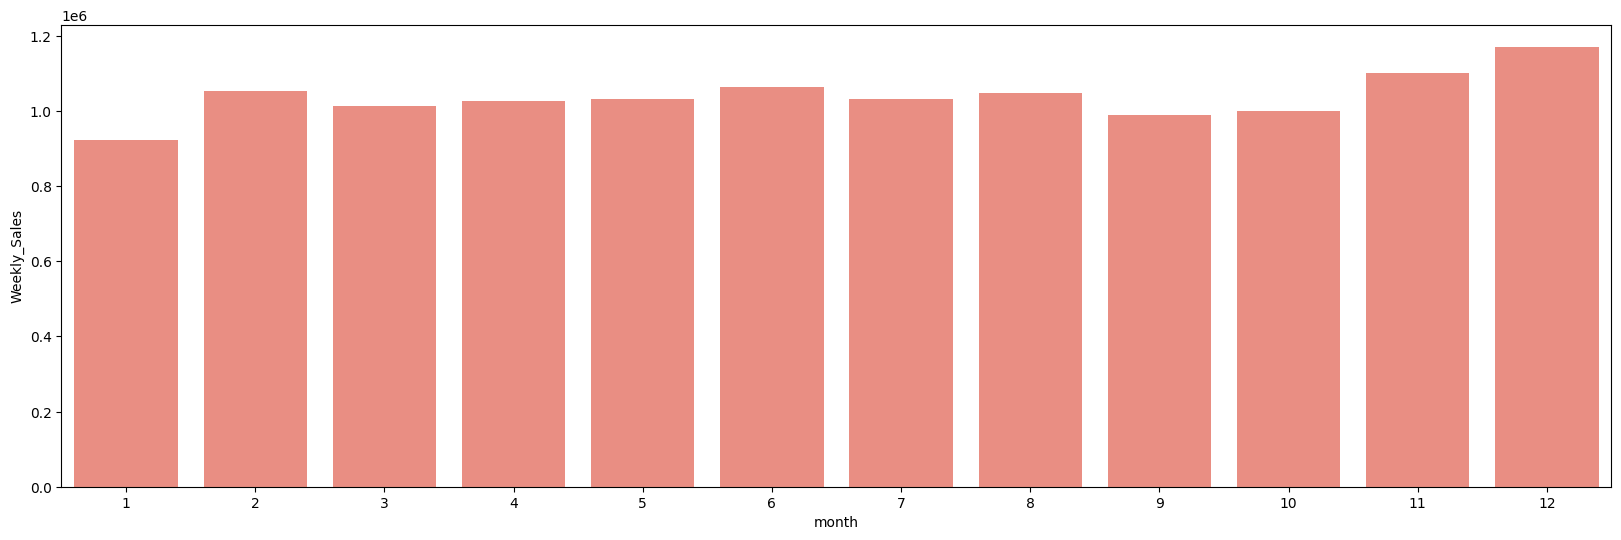

In [ ]:
plt.figure(figsize=(20,6))
fig = sns.barplot(x='month', y='Weekly_Sales', data=df,color='salmon', errorbar=None)

Khi nhìn vào biểu đồ trên, có thể thấy rằng doanh số tốt nhất là vào tháng 12 và tháng 11, như mong đợi. Các giá trị cao nhất thuộc về kỳ nghỉ Thanksgiving, nhưng khi tính trung bình, rõ ràng tháng 12 có giá trị tốt nhất.

* Mặc dù cửa hàng 10 và 35 đôi khi có giá trị doanh số hàng tuần cao hơn, trung bình chung cửa hàng 20 và cửa hàng 4 đứng ở vị trí thứ nhất và thứ hai. Điều này có nghĩa là một số khu vực có doanh số theo mùa cao hơn.
Như mong đợi, doanh số trung bình trong kỳ nghỉ cao hơn so với các ngày bình thường.

* Kỳ nghỉ Christmas được giới thiệu là những ngày cuối năm. Nhưng mọi người thường mua sắm vào tuần thứ 51. Vì vậy, khi chúng ta nhìn vào tổng doanh số của các kỳ nghỉ, Thanksgiving có doanh số cao hơn giữa chúng, được Walmart chỉ định.

* Năm 2010 có doanh số cao hơn năm 2011 và 2012. Nhưng, doanh số tháng 11 và tháng 12 không có trong dữ liệu cho năm 2012. Ngay cả khi không có các tháng có doanh số cao nhất, năm 2012 không thấp hơn đáng kể so với năm 2010, vì vậy sau khi thêm hai tháng cuối cùng, nó có thể đứng đầu.

* Rõ ràng là tuần 51 và 47 có giá trị cao hơn và các tuần 50-48 theo sau chúng. Thú vị là, doanh số cao thứ 5 thuộc về tuần thứ 22 của năm. Kết quả này cho thấy Christmas, Thanksgiving và Black Friday rất quan trọng hơn các tuần khác cho doanh số và thời gian quan trọng thứ 5 là tuần thứ 22 của năm và đó là cuối tháng 5, khi các trường học đóng cửa. Rất có thể, mọi người đang chuẩn bị cho kỳ nghỉ vào cuối tháng 5.

* Doanh số tháng 1 thấp hơn đáng kể so với các tháng khác. Đây là kết quả của doanh số cao vào tháng 11 và tháng 12. Sau hai tháng doanh số cao, mọi người thích chi tiêu ít hơn vào tháng 1.


## Numerical Features

In [ ]:
# vẽ distribution plot cho numeric feature
def draw_numeric_dist(df, feature):
    ax = sns.kdeplot(df[feature], fill=True)
    plt.grid(True)
    ax.set_title(f'{feature}\'s Distribution', fontdict={'fontsize': 18})
def draw_numeric_target_scatter(df, feature):
    ax = sns.scatterplot(data=df, x=feature, y='Weekly_Sales') #
    ax.set_title(f'{feature} vs Weekly_Sales', fontdict={'fontsize': 18})
    plt.grid(True)

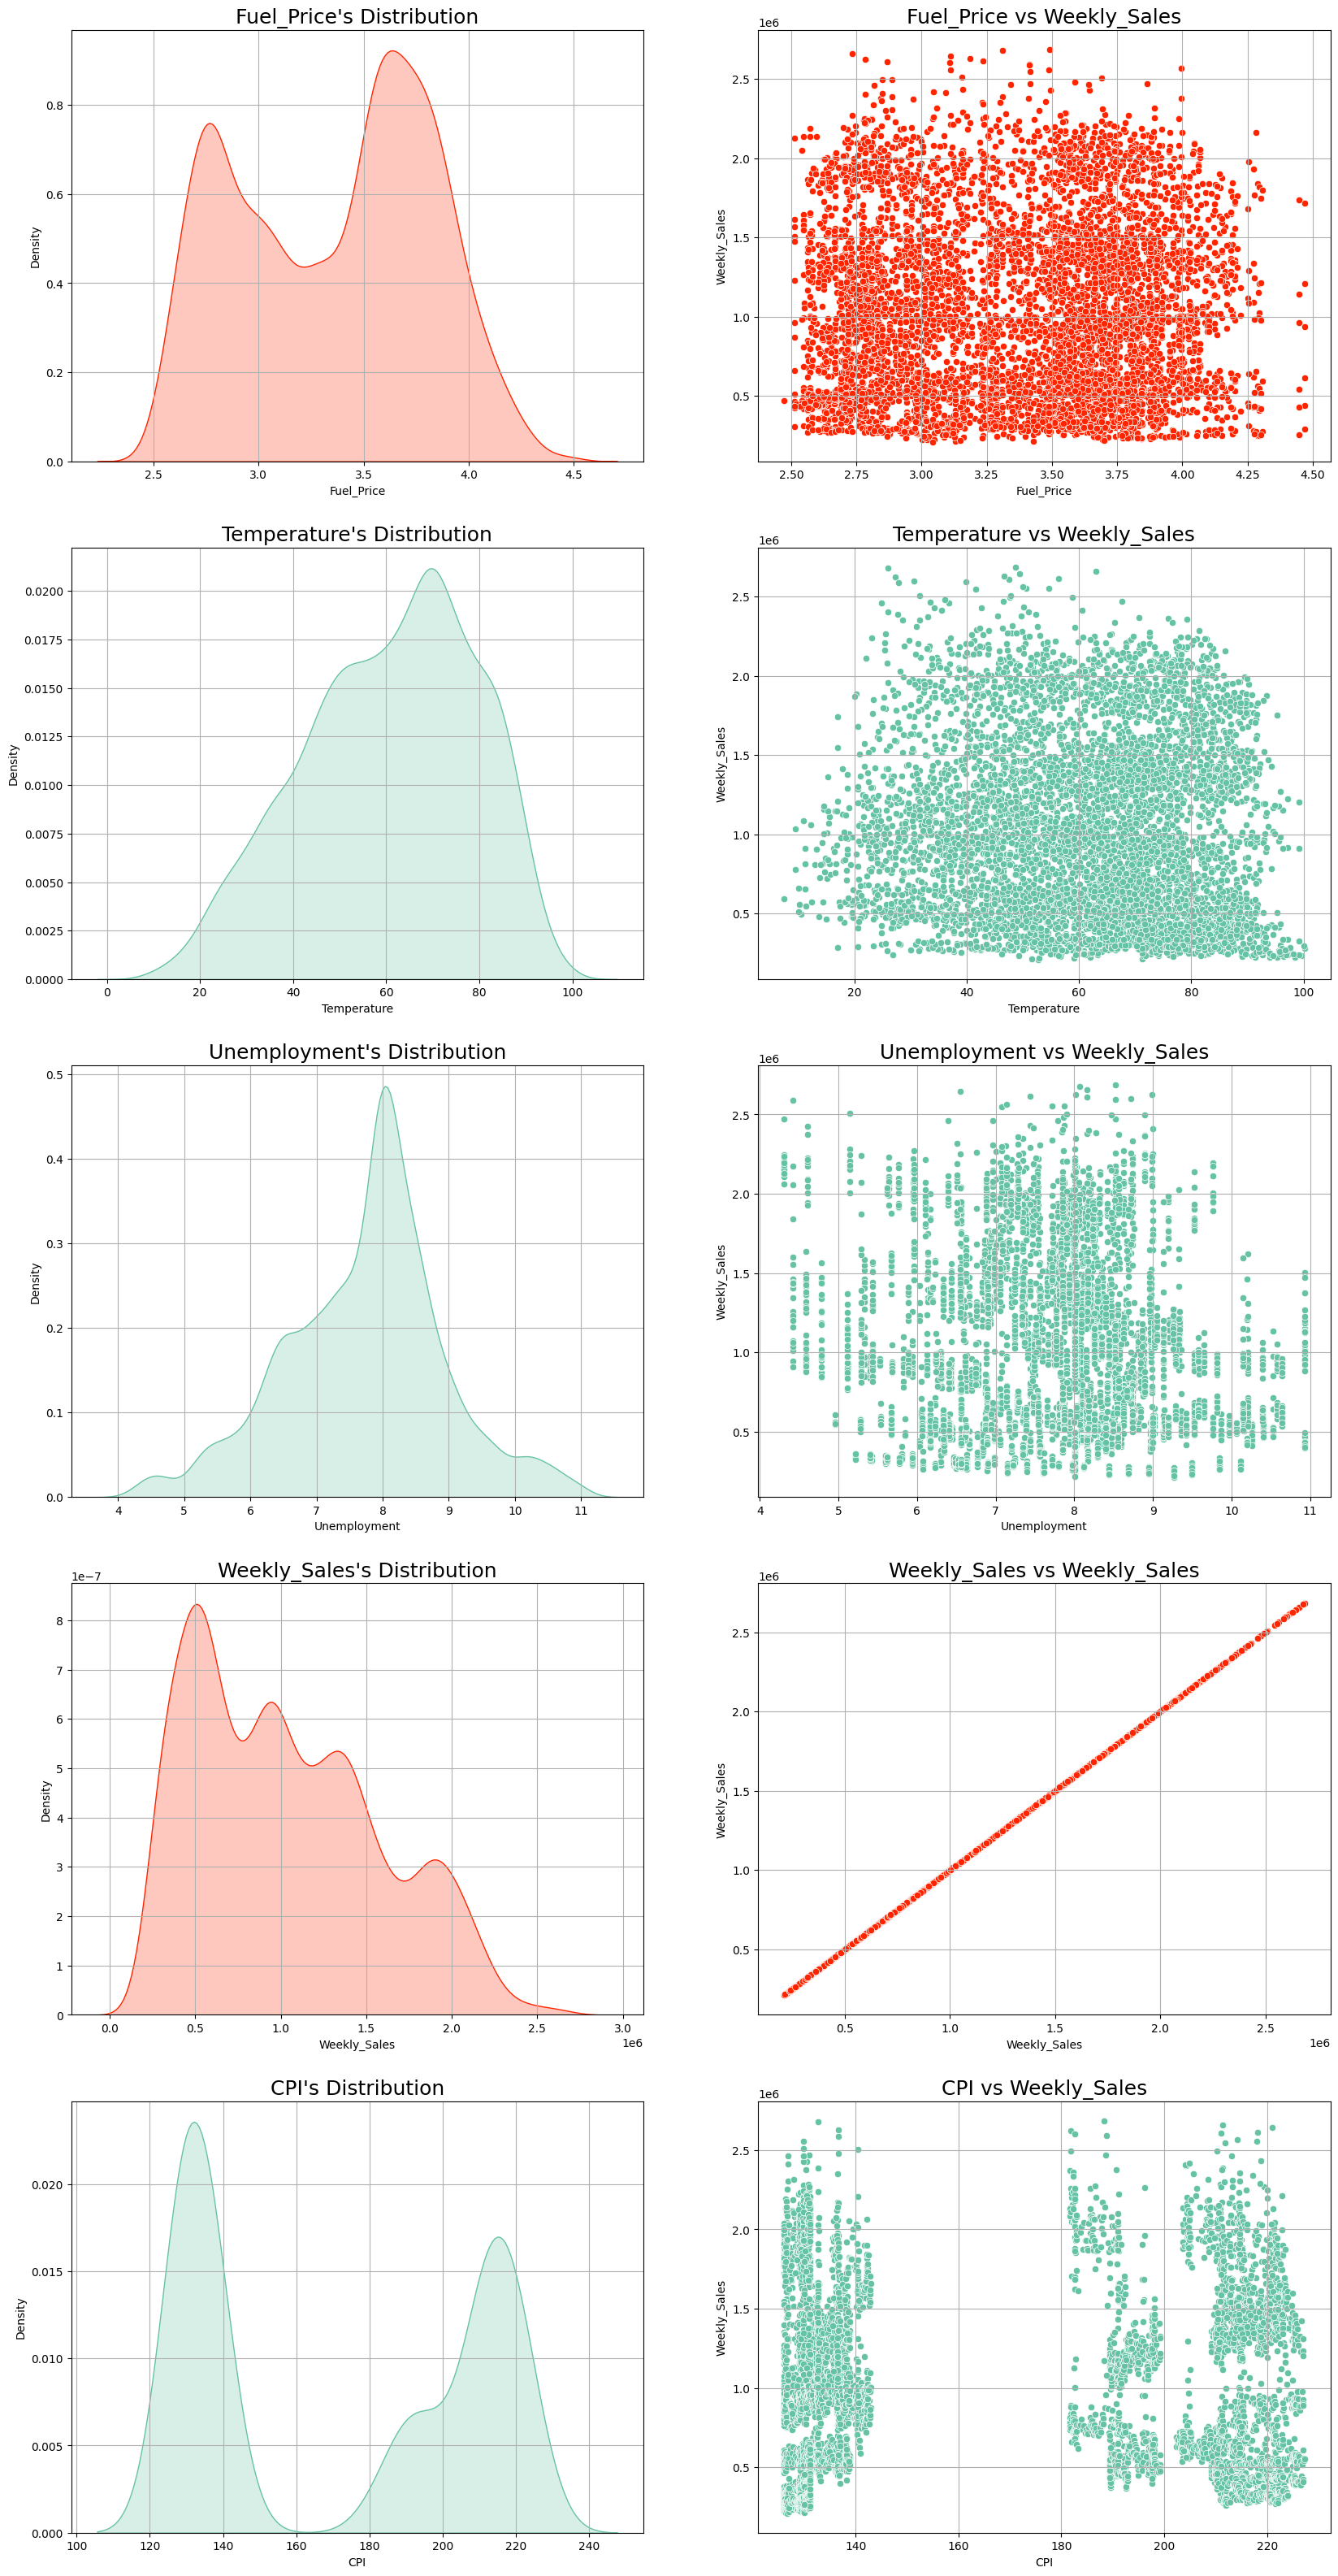

In [ ]:
plt.figure(figsize=(20,40))
palettes = ['Set1', 'Set2', 'Set3', 'autumn', 'cool']
for i, feature in enumerate(numeric_features):
    sns.set_palette(random.choice(palettes))
    # distribution
    plt.subplot(len(numeric_features), 2, i+i+1)
    draw_numeric_dist(df, feature)
    # scatter
    plt.subplot(len(numeric_features), 2, i+i +2)
    draw_numeric_target_scatter(df, feature)

plt.show()

* Nhiệt độ:
  * Phân phối: Phân phối của nhiệt độ có hình dạng chuông, tập trung quanh một giá trị trung bình. Điều này cho thấy nhiệt độ có xu hướng ổn định trong khoảng thời gian được xem xét.
  * Mối quan hệ với doanh số: Biểu đồ tán xạ không cho thấy một mối quan hệ rõ ràng giữa nhiệt độ và doanh số hàng tuần. Có thể có nhiều yếu tố khác ảnh hưởng đến doanh số hơn là nhiệt độ.
* Tỷ lệ thất nghiệp:
  * Phân phối: Sau khi thay outliers bằng giá trị trung bình, phân phối của tỷ lệ thất nghiệp trở nên mượt hơn, giảm độ lệch phải. Điều này cho thấy dữ liệu đã ổn định hơn và ít bị ảnh hưởng bởi các giá trị cực đoan.
  * Mối quan hệ với doanh số: Có vẻ như có một xu hướng tăng nhẹ của doanh số khi tỷ lệ thất nghiệp tăng, nhưng mối quan hệ này không rõ ràng và có nhiều điểm dữ liệu phân tán.
* Chỉ số giá tiêu dùng (CPI):

  * Phân phối: Phân phối của CPI hơi lệch phải, tương tự như tỷ lệ thất nghiệp.
  * Mối quan hệ với doanh số: Có một xu hướng tăng nhẹ của doanh số khi CPI tăng, nhưng mối quan hệ không rõ ràng và có nhiều điểm dữ liệu phân tán.
* Giá nhiên liệu:
  * Phân phối: Phân phối của giá nhiên liệu có hình dạng chuông, tập trung quanh một giá trị trung bình.
  * Mối quan hệ với doanh số: Không có mối quan hệ tuyến tính rõ ràng giữa giá nhiên liệu và doanh số.

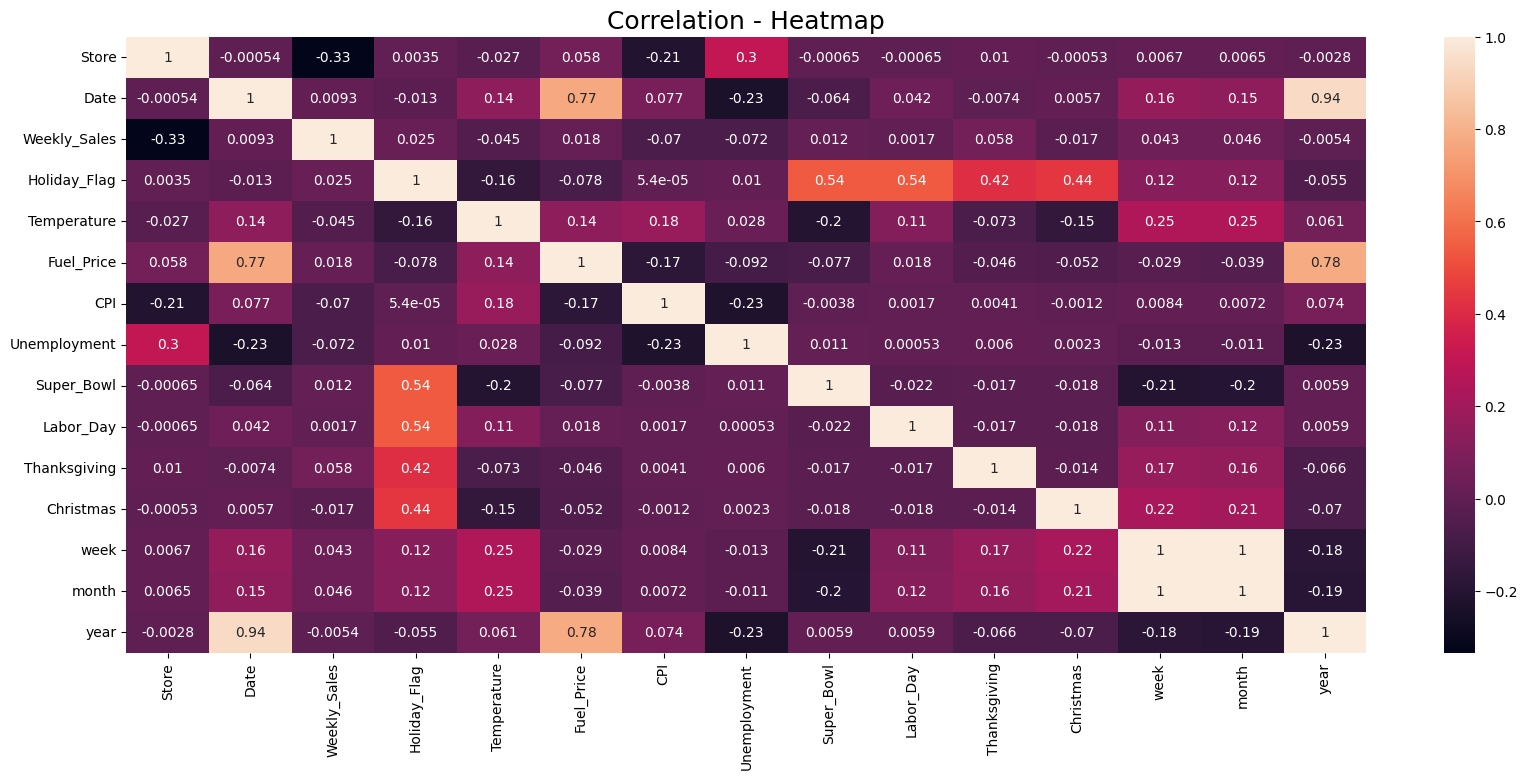

In [ ]:
# heatmap of correlation between features
plt.figure(figsize=(20, 8))
ax = sns.heatmap(df.corr(), annot=True)
ax.set_title('Correlation - Heatmap', fontdict={'fontsize': 18})
plt.show()

Dưới đây là một số nhận xét cơ bản về các mối quan hệ giữa các biến:

1. **Tương quan giữa `Weekly_Sales` và các biến khác:**
   - `Weekly_Sales` có tương quan yếu với hầu hết các biến. Cụ thể:
     - Với `Holiday_Flag`, có một mối tương quan nhẹ tích cực (0.03), cho thấy doanh thu tuần có thể có sự thay đổi nhẹ trong các kỳ lễ.
     - Không có mối tương quan mạnh với `Temperature`, `Fuel_Price`, `CPI`, `Unemployment`, v.v., điều này có thể chỉ ra rằng các yếu tố này không phải là yếu tố chính ảnh hưởng đến doanh thu.
     - `Super_Bowl`, `Labor_Day`, `Thanksgiving`, và `Christmas` có tương quan thấp, đặc biệt là với `Weekly_Sales`, cho thấy những sự kiện lễ hội này không có tác động đáng kể tới doanh thu trong dữ liệu.

2. **Tương quan giữa các chỉ số kinh tế:**
   - `Fuel_Price` có mối tương quan mạnh với `CPI` (0.78), có thể cho thấy mối quan hệ giữa giá xăng dầu và chỉ số giá tiêu dùng trong nền kinh tế.


3. **Một số điểm đặc biệt:**
   - `year` có mối tương quan mạnh với `CPI` (0.78), chỉ ra rằng sự thay đổi trong các yếu tố thời gian có thể ảnh hưởng đến các yếu tố kinh tế vĩ mô trong dài hạn.
   - Các mối tương quan nhỏ như vậy có thể chỉ ra rằng dữ liệu của bạn không có sự thay đổi mạnh mẽ giữa các biến và có thể cần thêm các yếu tố khác để giải thích được các mối quan hệ giữa doanh thu và các yếu tố liên quan.

### Tổng kết:
- Dữ liệu của bạn cho thấy các yếu tố kinh tế và thời gian có tương quan không mạnh với doanh thu, có thể do đặc điểm của ngành hàng hoặc các yếu tố khác không được bao quát trong bộ dữ liệu này.
- Mối quan hệ giữa các kỳ nghỉ lễ và doanh thu có vẻ yếu, nhưng vẫn có một số yếu tố nhất định như `Holiday_Flag` có thể có ảnh hưởng nếu bạn phân tích chi tiết hơn.


# 4- Modeling

In [ ]:
# thử cái này xem sao, dựa vào mi score
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5850 entries, 0 to 6434
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         5850 non-null   int64         
 1   Date          5850 non-null   datetime64[ns]
 2   Weekly_Sales  5850 non-null   float64       
 3   Holiday_Flag  5850 non-null   int64         
 4   Temperature   5850 non-null   float64       
 5   Fuel_Price    5850 non-null   float64       
 6   CPI           5850 non-null   float64       
 7   Unemployment  5850 non-null   float64       
 8   Super_Bowl    5850 non-null   object        
 9   Labor_Day     5850 non-null   object        
 10  Thanksgiving  5850 non-null   object        
 11  Christmas     5850 non-null   object        
 12  week          5850 non-null   UInt32        
 13  month         5850 non-null   int32         
 14  year          5850 non-null   int32         
dtypes: UInt32(1), datetime64[ns](1), float64(5)

In [ ]:
# X = df[['CPI', 'Unemployment', 'Store']]

X = df.drop('Weekly_Sales', axis=1) # các features - dùng để dự đoán target variable
y = df['Weekly_Sales'] # target variable

### Feature selection sử dụng độ đo mutual information (MI)

<div style='padding:20px; background:lightgreen;color:black;border-radius:10px'>
    <b>Mutual Information (MI)</b>:<br />    
    - Đo sự ảnh hưởng của feature đối với target variable.<br />
    - Giá trị càng cao, thì feature đó càng ảnh hưởng đến target variable <br />
    <b>Lưu ý: MI chỉ hoạt động với dữ liệu dạng số (numeric data)</b>
    </div>

In [ ]:
from sklearn.feature_selection import mutual_info_regression

def get_mi_score(X, y):
    mi = mutual_info_regression(X, y, random_state = 42)
    mi = pd.Series(mi, index = X.columns).sort_values(ascending=False)
    return mi

In [ ]:
# Convert the 'Date' column to numerical features
X['Date'] = X['Date'].apply(lambda date: date.toordinal())

#Then calculate MI score
mi_score = get_mi_score(X, y)
print(mi_score)

Store          1.72
Unemployment   0.73
CPI            0.52
Temperature    0.06
Fuel_Price     0.05
month          0.03
year           0.02
Date           0.02
Super_Bowl     0.00
Holiday_Flag   0.00
Thanksgiving   0.00
week           0.00
Labor_Day      0.00
Christmas      0.00
dtype: float64


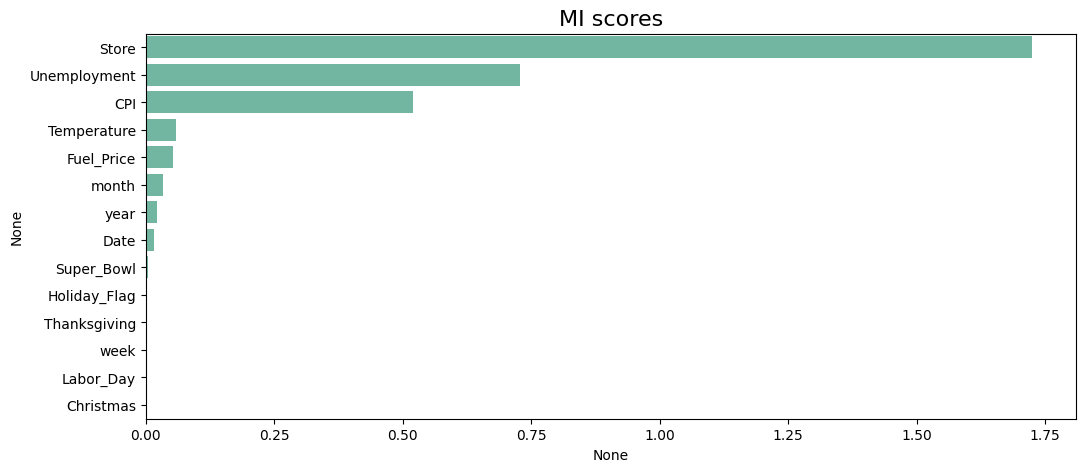

In [ ]:
# trực quan MI score của các features đối với 'price'
plt.figure(figsize=(12, 5))
ax = sns.barplot(y=mi_score.index[0:], x=mi_score[0:])
ax.set_title('MI scores', fontdict={'fontsize': 16})
plt.show()

In [ ]:
# drop yr_renovated
X.drop(['Thanksgiving','Super_Bowl','Labor_Day','Christmas','week','Holiday_Flag'], axis=1, inplace=True)

### Xây dựng và đánh giá mô hình


Thực hiện phân chia dữ liệu cho quá trình huấn luyện (training) và kiểm tra (testing)


In [ ]:
from sklearn.model_selection import train_test_split

# dữ liệu được chia: 80% cho training và 20% cho testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 42)


Khởi tạo và huấn luyện mô hình



Đánh giá mô hình


In [ ]:
from sklearn.model_selection import GridSearchCV

# Định nghĩa các tham số cần tối ưu
param_grid = {
    'n_estimators': range(10, 101, 1),
    'max_depth': range(1, 31),
    'min_samples_split': range(2, 11),
    'min_samples_leaf': range(2, 11)
}

# Tìm tham số tối ưu
grid_search = GridSearchCV(RandomForestRegressor(), param_grid, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# Lấy kết quả tốt nhất
print("Best parameters found: ", grid_search.best_params_)

In [ ]:
# khởi tạo và huấn luyện mô hình sử dụng tập train
model = RandomForestRegressor(n_estimators=200, max_depth=30, min_samples_split=5, min_samples_leaf=1)
model.fit(X_train, y_train)

# thực hiện dự đoán trên tập test
random_y_pred = model.predict(X_test)
random_mse = mean_squared_error(y_test, random_y_pred)
random_rmse = np.sqrt(random_mse)
random_mae = mean_absolute_error(y_test, random_y_pred)
random_r_2 = r2_score(y_test, random_y_pred)

print('MSE: ', "{:,.4f}".format(random_mse))
print('RMSE: ', "{:,.4f}".format(random_rmse))
print('MAE: ', "{:,.4f}".format(random_mae))
print('R^2:', "{:,.4f}".format(random_r_2))

MSE:  14,348,330,151.5656
RMSE:  119,784.5155
MAE:  66,104.5783
R^2: 0.9511


In [ ]:
xgb_model = xgb.XGBRegressor(objective='reg:squarederror',  n_estimators=200,
    max_depth=30,
    min_child_weight=5,
    subsample=0.8,
    learning_rate=0.1,
    random_state=42)
xgb_model.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_pred_xgb = xgb_model.predict(X_test)

# Đánh giá mô hình
xgb_mse = mean_squared_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(xgb_mse)
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_r_2 = r2_score(y_test, y_pred_xgb)

print('MSE: ', "{:,.4f}".format(xgb_mse))
print('RMSE: ', "{:,.4f}".format(xgb_rmse))
print('MAE: ', "{:,.4f}".format(xgb_mae))
print('R^2:', "{:,.4f}".format(xgb_r_2))


MSE:  8,307,137,949.2047
RMSE:  91,143.5020
MAE:  55,022.7945
R^2: 0.9717


In [ ]:
gb_model = GradientBoostingRegressor(n_estimators=200,max_depth=30,
                                     min_samples_split=5, min_samples_leaf=1, learning_rate=0.1,random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

gb_mse = mean_squared_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(gb_mse)
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_r_2 = r2_score(y_test, y_pred_gb)

print('Gradient Boosting Model Evaluation:')
print('MSE: ', "{:,.4f}".format(gb_mse))
print('RMSE: ', "{:,.4f}".format(gb_rmse))
print('MAE: ', "{:,.4f}".format(gb_mae))
print('R^2:', "{:,.4f}".format(gb_r_2))

Gradient Boosting Model Evaluation:
MSE:  21,475,484,766.1562
RMSE:  146,545.1629
MAE:  75,934.6726
R^2: 0.9268


In [ ]:
lgb_model = lgb.LGBMRegressor(objective='regression', n_estimators=200,
    max_depth=30,
    min_data_in_leaf=5,  # Tương tự min_samples_leaf
    subsample=0.8,
    learning_rate=0.1,
    random_state=42)
lgb_model.fit(X_train, y_train)


y_pred_lgb = lgb_model.predict(X_test)
lgb_mse = mean_squared_error(y_test, y_pred_lgb)
lgb_rmse = np.sqrt(lgb_mse)
lgb_mae = mean_absolute_error(y_test, y_pred_lgb)
lgb_r_2 = r2_score(y_test, y_pred_lgb)

print('LightGBM Model Evaluation:')
print('MSE: ', "{:,.4f}".format(lgb_mse))
print('RMSE: ', "{:,.4f}".format(lgb_rmse))
print('MAE: ', "{:,.4f}".format(lgb_mae))
print('R^2:', "{:,.4f}".format(lgb_r_2))

[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001219 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1214
[LightGBM] [Info] Number of data points in the train set: 5118, number of used features: 8
[LightGBM] [Info] Start training from score 1035679.676656
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
LightGBM Model Evaluation:
MSE:  6,049,848,594.9792
RMSE:  77,780.7727
MAE:  48,437.6328
R^2: 0.9794


In [ ]:
data = {
    'Model': ['RandomForest', 'XGBoost', 'GradientBoosting', 'LightGBM'],
    'MSE': [random_mse, xgb_mse, gb_mse, lgb_mse],
    'RMSE': [random_rmse, xgb_rmse, gb_rmse, lgb_rmse],
    'MAE': [random_mae, xgb_mae, gb_mae, lgb_mae],
    'R^2': [random_r_2, xgb_r_2, gb_r_2, lgb_r_2]
}

results_df = pd.DataFrame(data)
results_df

,Model,MSE,RMSE,MAE,R^2
0,RandomForest,"14,348,330,151.57","119,784.52","66,104.58",0.95
1,XGBoost,"8,307,137,949.20","91,143.50","55,022.79",0.97
2,GradientBoosting,"21,475,484,766.16","146,545.16","75,934.67",0.93
3,LightGBM,"6,049,848,594.98","77,780.77","48,437.63",0.98


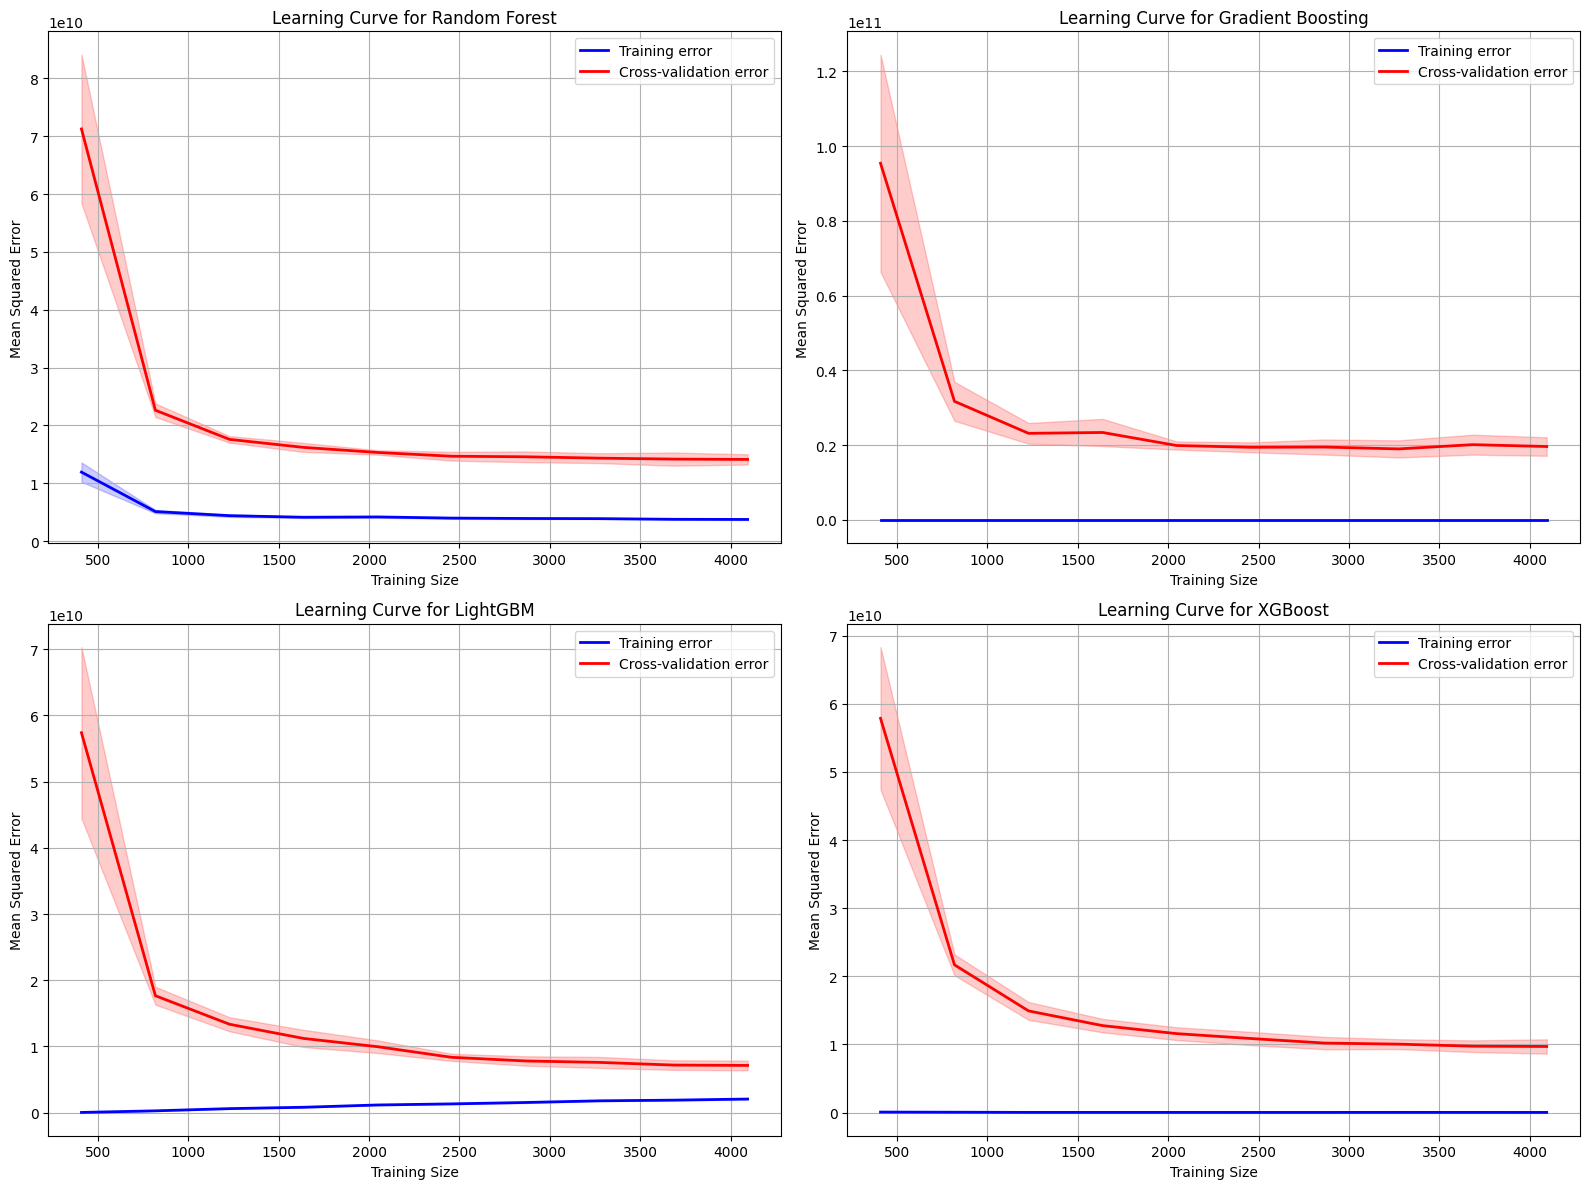

In [ ]:
# Function to plot learning curve for a single model
def plot_learning_curve(model, title, X_train, y_train, ax):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train, y_train, cv=5, scoring='neg_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
    )

    train_scores_mean = -train_scores.mean(axis=1)
    test_scores_mean = -test_scores.mean(axis=1)
    train_scores_std = train_scores.std(axis=1)
    test_scores_std = test_scores.std(axis=1)

    ax.plot(train_sizes, train_scores_mean, label="Training error", color="blue", lw=2)
    ax.plot(train_sizes, test_scores_mean, label="Cross-validation error", color="red", lw=2)

    ax.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, color="blue", alpha=0.2)
    ax.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, color="red", alpha=0.2)

    ax.set_title(title)
    ax.set_xlabel("Training Size")
    ax.set_ylabel("Mean Squared Error")
    ax.legend(loc="best")
    ax.grid(True)

# Creating a 2x2 grid for the plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plotting learning curves for each model
plot_learning_curve(model, "Learning Curve for Random Forest", X_train, y_train, axes[0, 0])
plot_learning_curve(gb_model, "Learning Curve for Gradient Boosting", X_train, y_train, axes[0, 1])
plot_learning_curve(lgb_model, "Learning Curve for LightGBM", X_train, y_train, axes[1, 0])
plot_learning_curve(xgb_model, "Learning Curve for XGBoost", X_train, y_train, axes[1, 1])

plt.tight_layout()
plt.show()


1. Hiệu suất tổng thể:
  * Random Forest (mô hình chính): Mặc dù là mô hình chính được sử dụng, nhưng hiệu suất tổng thể thấp hơn các mô hình khác, với lỗi kiểm tra cao hơn và có dấu hiệu overfitting trên tập dữ liệu này.
  * Gradient Boosting: Hiệu suất khá tốt, nhưng lỗi kiểm tra vẫn cao hơn XGBoost và LightGBM, đặc biệt khi kích thước dữ liệu lớn.
  * XGBoost và LightGBM: Thể hiện hiệu năng vượt trội, với lỗi kiểm tra thấp nhất và khả năng tổng quát hóa tốt hơn khi so với Random Forest.
2. Overfitting:
  * Random Forest: Có dấu hiệu overfitting rõ rệt, với lỗi huấn luyện rất thấp nhưng lỗi kiểm tra cao. Điều này cho thấy mô hình kém khả năng tổng quát trên dữ liệu mới.
  * Gradient Boosting: Có dấu hiệu overfitting nhẹ ở giai đoạn đầu nhưng giảm dần khi kích thước dữ liệu tăng.
  * XGBoost và LightGBM: Ít bị overfitting hơn nhờ các cơ chế regularization hiệu quả.
3. Tối ưu hóa với dữ liệu lớn:
  * Random Forest: Hội tụ chậm hơn và hiệu suất giảm khi kích thước dữ liệu tăng.
  * XGBoost và LightGBM: Hoạt động ổn định và hiệu quả hơn, đặc biệt với dữ liệu lớn.